In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [ ]:
class TempratureState(TypedDict):
    temp_celcius:float
    temp_faranhit:float
    weather_status:str

In [3]:
def convert_temprature(state:TempratureState) ->TempratureState:
    celcius=state['temp_celcius']
    farahit=(celcius*1.8)+32
    state['temp_faranhit']=round(farahit,2)
    return state

In [ ]:
def labelweaather(state:TempratureState) -> TempratureState:
    if state['temp_faranhit']>=50:
        state['weather_status']=='hot'
    elif state['temp_faranhit']>=25:
     state['weather_status']=='noraml'
    elif state['temp_faranhit']>=75:
          state['weather_status']=='hot'
    return state
    

In [5]:
graph=StateGraph(TempratureState)
graph.add_node('converttemprature',convert_temprature)
graph.add_edge(START,'converttemprature')
graph.add_edge('converttemprature',END)

In [ ]:
braphbuild=graph.compile()

In [7]:
intialstate={ 'temp_celcius' :54.8}
final_state=braphbuild.invoke(intialstate)
print(final_state)

{'temp_celcius': 54.8, 'temp_faranhit': 130.64}


Visualize grpah

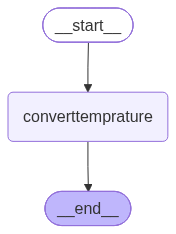

In [8]:
from IPython.display import Image
Image(braphbuild.get_graph().draw_mermaid_png())